# Система прогнозирования продаж для компании, представляющей сеть дарксторов

## Описание задачи

Клиентом является компания, представляющая новую сеть дарксторов, специализирующуюся на быстрой доставке продуктов и товаров повседневного спроса. 

**Бизнес-проблема**

Точность управления запасами определяет эффективность дарксторов. Однако ручное планирование, основанное на субъективных оценках аналитиков, создает системные проблемы: дефицит в пиковые периоды снижает выручку на 3–5%, избыточные запасы ведут к списаниям скоропортящихся товаров (2–3% выручки), а сама процедура отнимает у специалистов по 15–20 часов еженедельно.

**Цель проекта**

Разработать автоматизированную систему прогнозирования недельных продаж для каждого отдела во всех дарксторах с использованием машинного обучения (модель CatBoost). Система будет работать в режиме пакетного внедрения с недельным циклом: модель будет переобучаться каждое воскресенье вечером, а к понедельнику утром прогнозы будут готовы для передачи в систему планирования закупок.

В ноутбуке выполним:

1. Первичный анализ и очистку данных.
2. Предобработку и создание признаков.
3. Мониторинг стабильности признаков (PSI).
4. Обучение модели CatBoost и оценку качества.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import psycopg2
from dotenv import load_dotenv

from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

Фиксируем `random_state` для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

### Шаг 1. Первичный анализ данных

Создадим соединение.

In [3]:
load_dotenv()

True

In [4]:
connection = psycopg2.connect(
    dbname=os.getenv('DB_NAME'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    port=os.getenv('DB_PORT')
)

Загрузим три таблицы из PostgreSQL: `sales`, `stores`, `features`

In [5]:
df_sales = pd.read_sql_query("SELECT * FROM sales", connection)
df_stores = pd.read_sql_query("SELECT * FROM stores", connection)
df_features = pd.read_sql_query("SELECT * FROM features", connection)

Проверим корректность выгрузки данных.

In [6]:
df_names = ['df_sales', 'df_stores', 'df_features']
dfs = [df_sales, df_stores, df_features]
for idx, df in enumerate(dfs):
    print(f'{'-' * 5} Датафрейм {df_names[idx]} {'-' * 5}')
    display(df.head(3))
    df.info()
    print()

----- Датафрейм df_sales -----


,store,dept,date,weekly_sales,is_holiday
0,1,1,2023-02-05,24924.50,False
1,29,5,2023-02-05,15552.08,False
2,29,6,2023-02-05,3200.22,False


<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   weekly_sales  421570 non-null  float64
 4   is_holiday    421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

----- Датафрейм df_stores -----


,store,type,size
0,1,A,151315
1,2,A,202307
2,3,B,37392


<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   store   45 non-null     int64
 1   type    45 non-null     str  
 2   size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB

----- Датафрейм df_features -----


,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,NaN,NaN,NaN,NaN,211.096358,8.106
1,29,5,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
2,29,6,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064


<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   temperature   421570 non-null  float64
 4   fuel_price    421570 non-null  float64
 5   factor1       421570 non-null  float64
 6   factor2       111248 non-null  float64
 7   factor3       137091 non-null  float64
 8   factor4       134967 non-null  float64
 9   factor5       151432 non-null  float64
 10  cpi           421570 non-null  float64
 11  unemployment  421570 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 38.6+ MB



Данные были выгружены успешно, признаки всех датафреймов соответствуют ожидаемым, кроме признака `dept` в `df_features` - в условиях задания его не было, но судя по двум другим таблицам, признак отвечает за номер отдела внутри даркстора и варьируется в пределах от 1 до 99.

Проанализируем типы данных, пропуски и необходимые преобразования признаков таблиц:

- Датафрейм `df_sales`:
	типы признаков соот-ют ожидаемым, но тип признака `date` необходимо изменить на временной, пропусков нет, в ходе подготовки данных необходимо будет привести true/false признака `is_holiday` к 1/0 соот-но. 
- Датафрейм `df_stores `:
	типы признаков соот-ют ожидаемым, пропусков нет.
- Датафрейм `df_features `:
	типы признаков соот-ют ожидаемым, но тип признака `date` необходимо изменить на временной, признаки `factor2`, `factor3`, `factor4`, `factor5` содержат пропуски.

Приведем даты к нужному типу данных.

In [7]:
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_features['date'] = pd.to_datetime(df_features['date'])

Все признаки с пропусками имеют числовые типы данных, для определения, дискретные они или непрерывные, посмотрим количество их уникальных значений.

In [8]:
for i in range(1, 6):
    print(f'factor{i}', df_features[f'factor{i}'].nunique())

factor1 2278
factor2 1499
factor3 1662
factor4 1944
factor5 2293


Во всех признаках много уникальных значений, они являются непрерывными. Изучим причины пропусков. 

Пропуски присутствуют только в MarkDown - признаках. Вероятно, они не являются аномалией, а просто говорят об отсутствии акций и скидок в данный временной период - неделю, окончившуюся в дату `date`. Скорее всего, пропуски можно отнести к MAR - так как они объясняются датами, в которые попадают. Поэтому заполним пропуски средним значением.

Заполним пропуски.

In [9]:
for i in range(1, 6):
    df_features[f'factor{i}'] = df_features[f'factor{i}'].fillna(df_features[f'factor{i}'].mean())

Проверим данные после заполнения пропусков.

In [10]:
for idx, df in enumerate(dfs):
    print(f'Датафрейм {df_names[idx]}')
    display(dfs[idx].isna().sum())

Датафрейм df_sales


store           0
dept            0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

Датафрейм df_stores


store    0
type     0
size     0
dtype: int64

Датафрейм df_features


store           0
dept            0
date            0
temperature     0
fuel_price      0
factor1         0
factor2         0
factor3         0
factor4         0
factor5         0
cpi             0
unemployment    0
dtype: int64

Пропусков в данных больше нет.

Проверим датафреймы на наличие полных дубликатов.

In [11]:
print('Количество полных дубликатов в датафреймах:')
for idx, df in enumerate(dfs):
    print(df_names[idx], dfs[idx].duplicated().sum())

Количество полных дубликатов в датафреймах:
df_sales 0
df_stores 0
df_features 0


Построим визуализацию суммы продаж за каждую неделю, чтобы увидеть распределение продаж по времени. Для этого сначала найдем сумму за каждую неделю. 

In [12]:
sales_sum_week = df_sales.groupby('date')['weekly_sales'].sum().reset_index(name='weekly_sales')

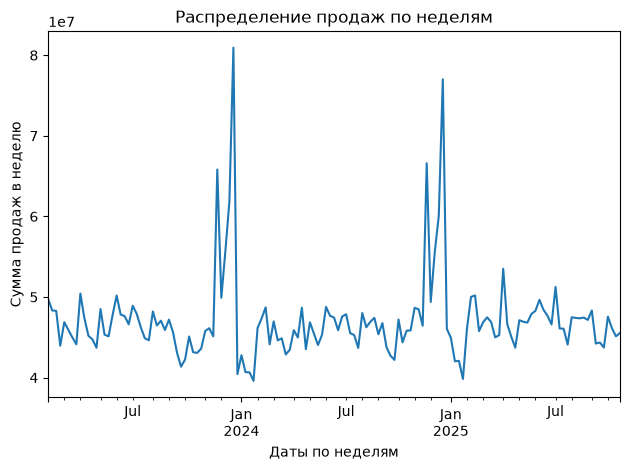

In [13]:
sales_sum_week.plot(x='date', 
                    y='weekly_sales', 
                    title='Распределение продаж по неделям',
                    xlabel='Даты по неделям',
                    ylabel='Сумма продаж в неделю',
                    legend=False
                    )
plt.tight_layout()

Построим распределение продаж по месяцам.

In [14]:
sales_sum_month = df_sales.groupby(df_sales['date'].dt.to_period('M'))['weekly_sales'].sum()

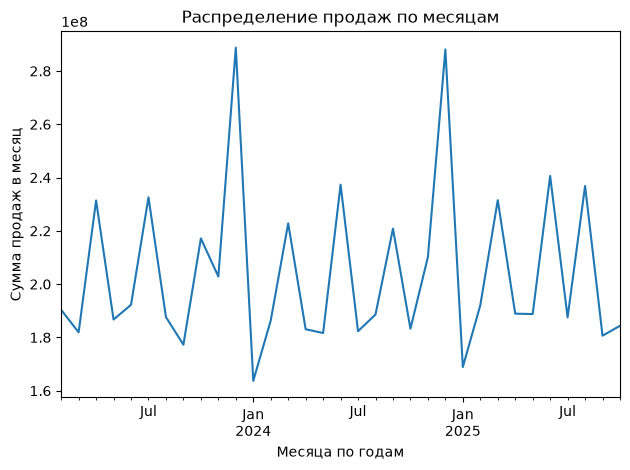

In [15]:
sales_sum_month.plot(title='Распределение продаж по месяцам',
                     xlabel='Месяца по годам',
                     ylabel='Сумма продаж в месяц')
plt.tight_layout()

Судя по графикам - в данных явно выражена сезонность - каждый год пик продаж приходится на конец декабря, самое начало января, после чего тут же следует наибольший упадок продаж за год - это можно связать с новогодними праздниками, в эти дни покупатели совершают нибольшее кол-во покупок. В подобные периоды (праздничные и предпраздничные дни) бизнес сталкивался с проблемой превышения запасов спросом - в таком случае можно закупать большее кол-во товаров именно в пиковые периоды (середина-конец декабря), а в январе уменьшить кол-во запасов, чтобы в дарксторах не оставались излишки в непиковые периоды.

В остальные периоды года сумма продаж держится примерно на одном и том же уровне - присутствуют всплески, при которых в некоторые месяцы продаж становится больше, в другие меньше, но изменения не так критичны, чтобы менять логику покупки запасов дарксторами - так как, например, в июле на момент 2023 года был локальный скачок продаж, в то время как в 2024 и 2025 году упадок - то есть продажи варьируются от года к году:

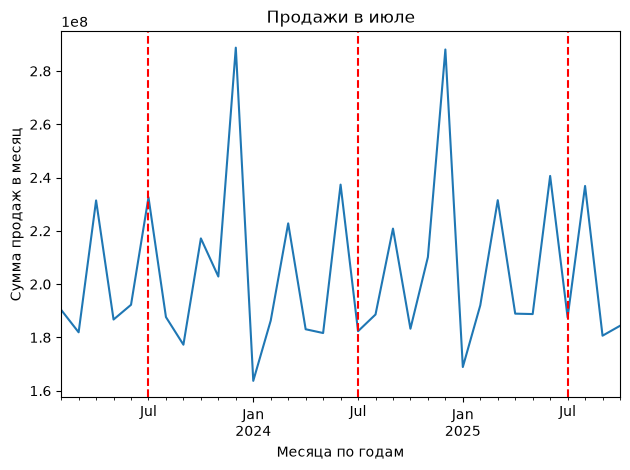

In [16]:
sales_sum_month.plot(title='Продажи в июле',
                     xlabel='Месяца по годам',
                     ylabel='Сумма продаж в месяц')
for year in range(2023, 2026):
    plt.axvline(x=pd.Timestamp(f'{year}-07-01'),
                color='red',
                linestyle='--')
plt.tight_layout()

Объединим три таблицы в одну для дальнейшего анализа.

In [17]:
df = df_sales.merge(df_stores, on='store', how='left')
df = df.merge(df_features, on=['store', 'dept', 'date'], how='left')

Посмотрим на результат объединения.

In [18]:
df.head(3)

,store,dept,date,weekly_sales,is_holiday,type,size,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,24924.50,False,A,151315,42.31,2.572,7028.8,3334.628621,1439.421384,3383.168256,4628.975079,211.096358,8.106
1,29,5,2023-02-05,15552.08,False,B,93638,24.36,2.788,7028.8,3334.628621,1439.421384,3383.168256,4628.975079,131.527903,10.064
2,29,6,2023-02-05,3200.22,False,B,93638,24.36,2.788,7028.8,3334.628621,1439.421384,3383.168256,4628.975079,131.527903,10.064


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype        
---  ------        --------------   -----        
 0   store         421570 non-null  int64        
 1   dept          421570 non-null  int64        
 2   date          421570 non-null  datetime64[s]
 3   weekly_sales  421570 non-null  float64      
 4   is_holiday    421570 non-null  bool         
 5   type          421570 non-null  str          
 6   size          421570 non-null  int64        
 7   temperature   421570 non-null  float64      
 8   fuel_price    421570 non-null  float64      
 9   factor1       421570 non-null  float64      
 10  factor2       421570 non-null  float64      
 11  factor3       421570 non-null  float64      
 12  factor4       421570 non-null  float64      
 13  factor5       421570 non-null  float64      
 14  cpi           421570 non-null  float64      
 15  unemployment  421570 non-null  float64      


Объединение прошло успешно, в данных для обуения модели остались только те данные, что несут полезную информацию о совершенных покупках.

Применим метод `.corr()` для расчёта корреляционной матрицы. Для этого выявим числовые признаки в данных.

In [20]:
num_cols = df.select_dtypes(['float64', 'int64', 'bool'])
num_cols.shape

(421570, 14)

Построенная корреляционная матрица представлена ниже.

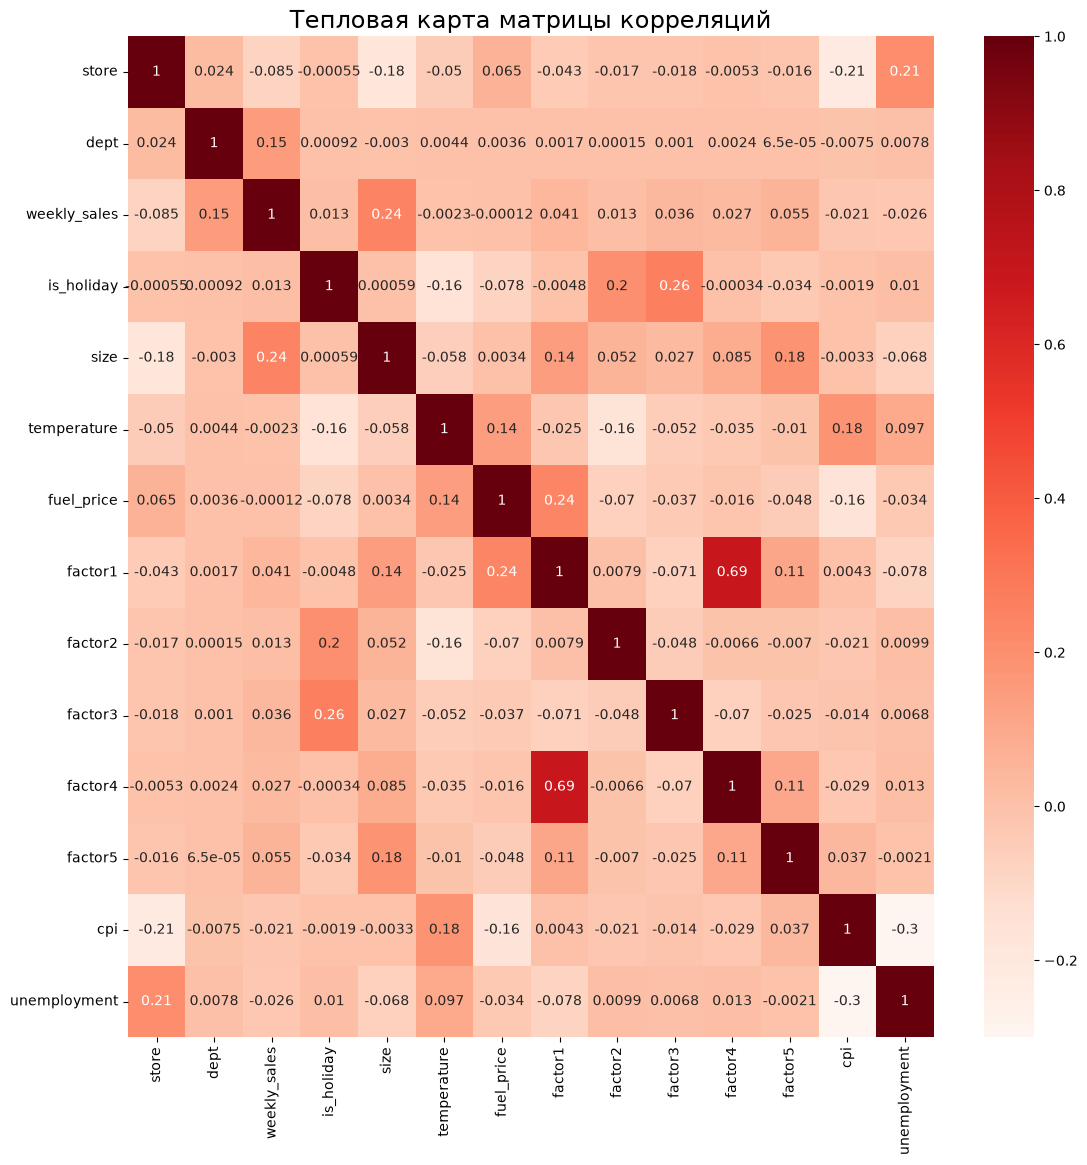

In [21]:
cor_matr = pd.DataFrame(num_cols.corr())
plt.figure(figsize=(13, 13))
sns.heatmap(cor_matr,
            annot=True,
            cmap='Reds')
plt.title('Тепловая карта матрицы корреляций', fontsize=17)
plt.show()

Мультиколлинеарности в признаках не наблюдается - сильнее всего коррелируют только признаки `factor4` и `factor1` (0.69), однако это значение все еще ниже порога, при котором признаки считались бы мультиколлинеарными.

Text(0.5, 1.0, 'Корреляция с продажами')

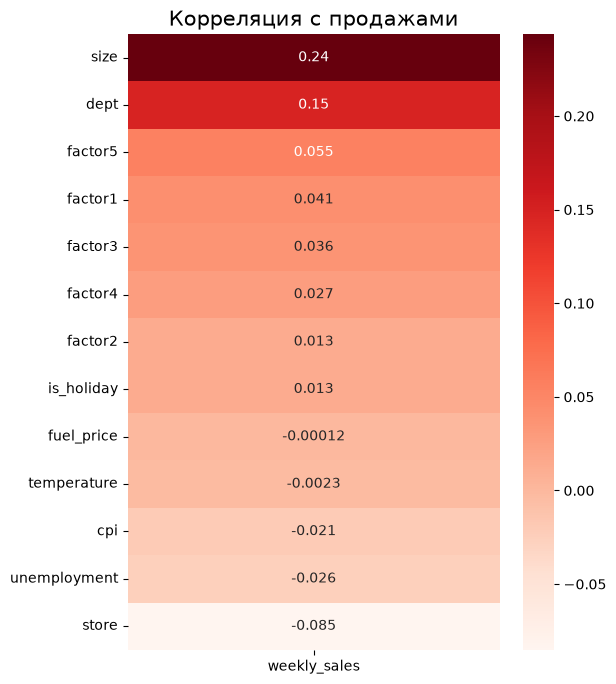

In [22]:
plt.figure(figsize=(6, 8))
sns.heatmap(cor_matr['weekly_sales'].sort_values(ascending=False).to_frame()[1:],
            cmap='Reds',
            annot=True)
plt.title('Корреляция с продажами', fontsize=15)

Как видно из рисунка - сильнее всего на продажи влияет размер даркстора `size` (0.24) и номер отдела `dept` (0.15) - скорее всего, чем больше магазин, тем больший выбор товар в нем возможен, за счет чего больше выручка. То же самое может быть связано и с отделами - в одним отделах дарксторы могут быть развиты лучше и быть больше - там прибыль будет выше, и наоборот.

Проверим статистические данные датасета.

In [23]:
df.describe(include='all')

,store,dept,date,weekly_sales,is_holiday,type,size,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
unique,NaN,NaN,NaN,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,False,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,391909,215478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,22.200546,44.260317,2024-06-17 08:30:31,15981.258123,NaN,NaN,136727.915739,60.090059,3.361027,10337.221240,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289
min,1.000000,1.000000,2023-02-05 00:00:00,-4988.940000,NaN,NaN,34875.000000,-2.060000,2.472000,7028.800000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000
25%,11.000000,18.000000,2023-10-08 00:00:00,2079.650000,NaN,NaN,93638.000000,46.680000,2.933000,7028.800000,3334.628621,115.390000,3383.168256,4628.975079,132.022667,6.891000
50%,22.000000,37.000000,2024-06-16 00:00:00,7612.030000,NaN,NaN,140167.000000,62.090000,3.452000,7028.800000,3334.628621,1439.421384,3383.168256,4628.975079,182.318780,7.866000
75%,33.000000,74.000000,2025-02-23 00:00:00,20205.852500,NaN,NaN,202505.000000,74.280000,3.738000,9431.920624,3334.628621,1439.421384,3383.168256,4628.975079,212.416993,8.572000
max,45.000000,99.000000,2025-10-26 00:00:00,693099.360000,NaN,NaN,219622.000000,100.140000,4.468000,103184.980000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000


Статистические данные выглядят корректно за исключением отрицательных значений продаж в `weekly_sales` (минимальное зн-ие достигает -4988). Проверим строки с подобными значениями.

In [24]:
print(f"""Отрицательные записи: {df[df['weekly_sales'] < 0].shape}
Нулевые записи: {df[df['weekly_sales'] == 0].shape}
Изначальный датафрейм: {df.shape}""")

Отрицательные записи: (1285, 16)
Нулевые записи: (73, 16)
Изначальный датафрейм: (421570, 16)


Отрицательных значений достаточно много - подобных записей 1285, что уже говорит о том, что это не пара случайных ошибок. Посмотрим на их распределение.

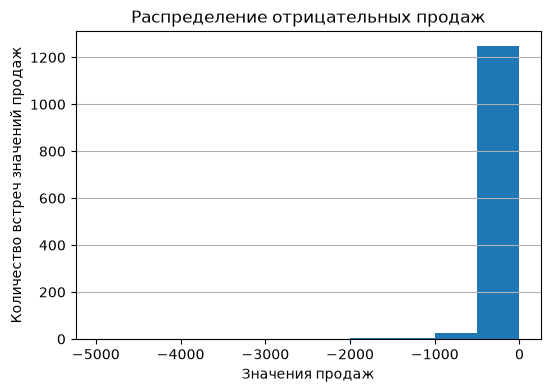

In [25]:
df[df['weekly_sales'] < 0]['weekly_sales'].plot(kind='hist', 
                                                bins=10,
                                                title='Распределение отрицательных продаж',
                                                figsize=(6, 4),
                                                xlabel='Значения продаж',
                                                ylabel='Количество встреч значений продаж').grid(axis='y')

Судя по графику, наибольшее количество отрицательных продаж сосредоточены возле значений от -1000 до 0. Из этого можно сделать вывод, что скорее всего, эти продажи являются возвратами пользователей - если бы значения были большими, то их можно было бы списать на технические сбои или бухгалтерские ошибки, но они достаточно небольшие. Так как это, вероятно, реальные транзакции, чтобы не терять информацию о них, оставим подобные записи, но заменим прибыль на 0. Так мы дадим понять модели, что даркстор работал в промежуток времени из подобной записи, но была совершена нестандартная операция.

In [26]:
df.loc[df['weekly_sales'] < 0, 'weekly_sales'] = 0
df[df['weekly_sales'] < 0].shape

(0, 16)

Найдем записи с очень высокими продажами (топ 0.01% или выше 99.99% квантиля). 

In [27]:
top_weekly_sales = df[df['weekly_sales'] > df['weekly_sales'].quantile(0.9999)]

Проверим, в какое время года они происходят.

In [28]:
top_weekly_sales.groupby(top_weekly_sales['date'].dt.to_period('M')).size().reset_index(name='Кол-во топ 0.01% продаж по месяцам')

,date,Кол-во топ 0.01% продаж по месяцам
0,2023-02,1
1,2023-11,17
2,2023-12,8
3,2024-11,14
4,2024-12,3


Проверим связь с праздниками.

In [29]:
print(f"""Доля праздников среди топ-продаж: {round(top_weekly_sales['is_holiday'].mean(), 3)}
Доля праздников во всем датасете: {round(df['is_holiday'].mean(), 3)}""")

Доля праздников среди топ-продаж: 0.721
Доля праздников во всем датасете: 0.07


Во всем датасете доля записей, относящихся к праздничным, составляет всего 7%, в то время как среди топа продаж целых 72% покупок были совершены в праздничные дни. Это говорит о явной связи очень больших продаж с праздниками - при учете изначально их небольшого количества, очень многие попали в топ-продажи. То есть данный анализ подтверждает выдвинутую выше гипотезу о том, что самые большие покупки зачастую совершаются в праздничные периоды. 

Проверим, с какими даркcторами связаны топовые продажи.

In [30]:
top_weekly_sales.groupby('store').size().reset_index(name='Кол-во топ 0.01% продаж по дарксторам').sort_values(by='Кол-во топ 0.01% продаж по дарксторам', ascending=False)

,store,Кол-во топ 0.01% продаж по дарксторам
3,10,6
1,4,5
6,14,5
10,20,3
14,28,2
4,12,2
9,19,2
8,18,2
11,22,2
2,6,2


Судя по статистике за предоставленный период - сильной зависимости высоких продаж от даркстора не прослеживается. Можно выделить 3 лидеров: 10, 4 и 14 дарксторы, но количество топовых продаж в них не сильно опережает оставшиеся дарксторы.

Проверим, с какими отделами связаны топовые продажи.

In [31]:
top_weekly_sales.groupby('dept').size().reset_index(name='Кол-во топ 0.01% продаж по отделам')

,dept,Кол-во топ 0.01% продаж по отделам
0,7,6
1,72,36
2,92,1


Среди отделов виден явный лидер - 36 из 43 топ-продаж были проведены в отделе 72. Это является важной закономерностью для модели - видимо, именно этот отдел является продовольственным либо сезонным и в праздники в нем совершается наибольшее количество покупок.

### Шаг 2. Предобработка признаков и feature engineering

Реализуем функцию `create_temporal_features` для извлечения временных признаков из столбца `Date`, которые помогут модели уловить сезонные паттерны.

Извлечем из даты:
- Месяц (`month`).
- Квартал (`quarter`).
- Год (`year`).

In [32]:
def create_temporal_features(df) -> pd.DataFrame:
    df = df.copy()

    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    return df

df = create_temporal_features(df)

In [33]:
assert 'month' in df.columns, 'Месяц не создан!'
assert 'quarter' in df.columns, 'Квартал не создан!'
assert 'year' in df.columns, 'Год не создан!'

Создадим агрегированные признаки в функции `create_avg_sales_feature` — средние продажи по комбинации «даркстор и отдел». Чтобы модель не использовала информацию из будущего, при создании агрегатов для каждой строки будем использовать только данные до даты из записи.

In [34]:
def create_avg_sales_feature(df):
    df = df.copy()

    df = df.sort_values(["store", "dept", "date"])

    
    df['avg_sales_before'] = df.groupby(['store', 'dept'])['weekly_sales'].transform(lambda x: x.shift().expanding().mean())

    return df

df = create_avg_sales_feature(df)

In [35]:
assert 'avg_sales_before' in df.columns, 'Признак средних продаж не создан!'

Создадим лаговые признаки в функции `create_lag_features` — продажи 1, 2 и 4 недели назад.

Лаговые признаки позволяют модели учитывать историю продаж:
- `sales_1week_ago` — продажи неделю назад.
- `sales_2week_ago` — продажи 2 недели назад.
- `sales_4week_ago` — продажи 4 недели назад.

In [36]:
def create_lag_features(df):
    df = df.copy()

    df = df.sort_values(["store", "dept", "date"])

    for i in [1, 2, 4]:
        df[f'sales_{i}week_ago'] = df.groupby(['store', 'dept'])['weekly_sales'].shift(i)

    return df


df = create_lag_features(df)

In [37]:
assert 'sales_1week_ago' in df.columns, 'Признак sales_1week_ago не создан!'
assert 'sales_2week_ago' in df.columns, 'Признак sales_2week_ago не создан!'
assert 'sales_4week_ago' in df.columns, 'Признак sales_4week_ago не создан!'

Создадим признаки скользящего среднего продаж за последние 2 и 4 недели в функции `create_rolling_features`. Эти признаки помогут уловить краткосрочные и среднесрочные тренды.

Скользящее среднее сглаживает колебания и показывает общий тренд:
- `mean_sales_2week` — среднее продаж за последние 2 недели.
- `mean_sales_4week` — среднее продаж за последние 4 недели.

In [38]:
def create_rolling_features(df):

    df = df.copy()

    df = df.sort_values(["store", "dept", "date"])

    df['mean_sales_2week'] = df.groupby(['store', 'dept'])['weekly_sales'].transform(lambda x: x.shift(1).rolling(2).mean())
    df['mean_sales_4week'] = df.groupby(['store', 'dept'])['weekly_sales'].transform(lambda x: x.shift(1).rolling(4).mean())

    return df

df = create_rolling_features(df)

In [39]:
assert 'mean_sales_2week' in df.columns, 'Признак mean_sales_2week не создан!'
assert 'mean_sales_4week' in df.columns, 'Признак mean_sales_4week не создан!'

Проверим корректность создания всех признаков на примере одного даркстора и отдела. Найдем такое сочетание даркстора и отдела, у которого достаточно большой кол-во записей.

In [40]:
df.groupby(['store', 'dept']).size().tail(1).reset_index()

,store,dept,0
0,45,98,135


Проверим корректность создания новых признаков.

In [41]:
new_features = [
    'date',
    'weekly_sales',
    'month', 
    'quarter', 
    'year', 
    'avg_sales_before', 
    'sales_1week_ago', 
    'sales_2week_ago', 
    'sales_4week_ago', 
    'mean_sales_2week', 
    'mean_sales_4week'
]

df[(df['store'] == 45) & (df['dept'] == 98)][new_features].head(6)

,date,weekly_sales,month,quarter,year,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago,mean_sales_2week,mean_sales_4week
2831,2023-02-05,347.23,2,1,2023,NaN,NaN,NaN,NaN,NaN,NaN
5662,2023-02-12,553.25,2,1,2023,347.230000,347.23,NaN,NaN,NaN,NaN
6601,2023-02-19,281.00,2,1,2023,450.240000,553.25,347.23,NaN,450.240,NaN
11305,2023-02-26,2.50,2,1,2023,393.826667,281.00,553.25,NaN,417.125,NaN
12623,2023-03-05,4.50,3,1,2023,295.995000,2.50,281.00,347.23,141.750,295.9950
14864,2023-03-12,18.50,3,1,2023,237.696000,4.50,2.50,553.25,3.500,210.3125


- Данные из даты извлечены корректно;
- `avg_sales_before` - средние продажи по предыдущим записям считаются корректно: первая строка `NaN`, остальные равны среднему от всех предыдущих - (347.23 + 553.25) / 2 = 450. 24 и т.д.;
- `sales_1week_ago`, `sales_2week_ago`, `sales_4week_ago` показывают продажи 1, 2 и 4 недели назад соот-но;
- `mean_sales_2week`, `mean_sales_4week` отображают среднее продаж за 2 и 4 недели: н-ер, для `mean_sales_2week` (347.23 + 553.25) / 2 = 450. 24, для `mean_sales_4week` (347.23 + 553.25 + 281.00 + 2.50) / 4 = 295.995.

Проверим пропуски в датафрейме.

In [42]:
df.isna().sum()

store                   0
dept                    0
date                    0
weekly_sales            0
is_holiday              0
type                    0
size                    0
temperature             0
fuel_price              0
factor1                 0
factor2                 0
factor3                 0
factor4                 0
factor5                 0
cpi                     0
unemployment            0
month                   0
quarter                 0
year                    0
avg_sales_before     3331
sales_1week_ago      3331
sales_2week_ago      6625
sales_4week_ago     13134
mean_sales_2week     6625
mean_sales_4week    13134
dtype: int64

In [43]:
before_delete = df.shape[0]
before_delete

421570

Удалим строки с пропусками, появившимися после создания лаговых и агрегированных признаков.

In [44]:
df = df.dropna()

In [45]:
print(f'Было удалено {round((before_delete - df.shape[0]) / before_delete * 100, 2)}% строк')

Было удалено 3.12% строк


### Шаг 3. Мониторинг стабильности признаков

Разделим данные на обучающую и валидационную выборки по времени:
- Обучающая выборка: февраль 2023 — август 2025.
- Валидационная выборка: сентябрь 2025 — октябрь 2025.

In [46]:
train_df = df[df['date'].dt.to_period('M') <= '2025-08'].copy()
val_df = df[(df['date'].dt.to_period('M') >= '2025-09') & (df['date'].dt.to_period('M') <= '2025-10')].copy()

Проверим размеры получившихся выборок.

In [47]:
train_df.shape

(384726, 25)

In [48]:
val_df.shape

(23710, 25)

Рассчитаем PSI для всех признаков для измерения стабильности распределения признаков между обучающей и валидационной выборками.

Напишем функцию для вычисления PSI.

In [49]:
def calculate_psi(expected, actual, buckets=10, epsilon=1e-10):
    breaks = np.linspace(min(min(expected), min(actual)),
                         max(max(expected), max(actual)),
                         buckets + 1)

    
    expected_bins = np.histogram(expected, bins=breaks)[0] / len(expected)
    actual_bins = np.histogram(actual, bins=breaks)[0] / len(actual)

    expected_bins = np.where(expected_bins == 0, epsilon, expected_bins)
    actual_bins = np.where(actual_bins == 0, epsilon, actual_bins)

    psi = sum((actual_bins[i] - expected_bins[i]) * np.log(actual_bins[i] / expected_bins[i]) for i in range(buckets))

    return psi

Отберем признаки, для которых будет проводить расчет.

In [50]:
num_cols = list(df.select_dtypes(['float', 'int']).columns)
for i in ['store', 'dept', 'weekly_sales']:
    num_cols.remove(i)

In [51]:
for col in num_cols:
    psi_value = calculate_psi(train_df[col], val_df[col])
    
    if psi_value >= 0.2:
        print(f'! Признак {col}, psi={psi_value} >= 0.2')
    else:
        print(f'Признак {col}, psi={psi_value}')

Признак size, psi=0.00011355889718070088
! Признак temperature, psi=3.1218596798868763 >= 0.2
! Признак fuel_price, psi=11.795402996116534 >= 0.2
! Признак factor1, psi=0.3314059871349533 >= 0.2
! Признак factor2, psi=0.45013515670920484 >= 0.2
Признак factor3, psi=0.11795658833105674
! Признак factor4, psi=0.27787481821195764 >= 0.2
Признак factor5, psi=0.14105995886907588
! Признак cpi, psi=1.0438500771664068 >= 0.2
! Признак unemployment, psi=1.4553845082860204 >= 0.2
! Признак month, psi=19.660634907496757 >= 0.2
! Признак quarter, psi=11.831662378630732 >= 0.2
! Признак year, psi=17.052201304869566 >= 0.2
Признак avg_sales_before, psi=0.0016778361173292325
Признак sales_1week_ago, psi=0.004458713301689958
Признак sales_2week_ago, psi=0.00443219559972522
Признак sales_4week_ago, psi=0.004563799663718046
Признак mean_sales_2week, psi=0.001692833791650081
Признак mean_sales_4week, psi=0.0024373405285356086


По результатам достаточно много значений PSI оказались выше 0,2. Стабильными оказались такие признаки - размеры дарксторов `size` и все созданные нами исторические признаки, за исключением временных признаков. Дрейф наблюдается для признаков с факторами рекламных акций и скидок - `factor3` (0.118), `factor5` (0.141). Остальные признаки оказались нестабильными - в особенности добавленные нами временные признаки.

Объяснить такой дрейф временных признаков можно тем, что в выборках используются данные за разные промежутки времени; так же от года к году сильно может меняться температура и цены на бензин, экономические факторы.

Визуализируем распределения некоторых признаков с высоким PSI на обучении и валидации.

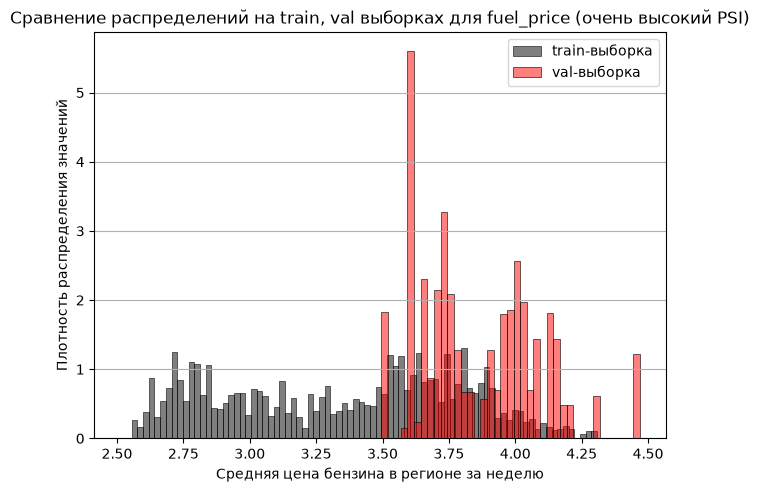

In [52]:
sns.histplot(train_df['fuel_price'], color='black', label='train-выборка', stat="density", alpha=0.5)
sns.histplot(val_df['fuel_price'], color='red', label='val-выборка', stat="density", alpha=0.5)
plt.tight_layout()
plt.title('Сравнение распределений на train, val выборках для fuel_price (очень высокий PSI)')
plt.xlabel('Средняя цена бензина в регионе за неделю')
plt.ylabel('Плотность распределения значений')
plt.legend()
plt.grid(axis='y')

Из графика видно, что у `fuel_price`, PSI которого составляет 11.795, имеются значительные различия форм распределений на тренировочной и валидационной выборках - для train-выборки гистограмма выглядит достаточно равномерно, нет явного доминирования каких-то значений над остальными, в то время как на валидационной выборке встречаются "провалы" - ямы, значения из которых почти не встречаются (например, значения 3.54-3.56), и пики, например, для значения около 3.6.

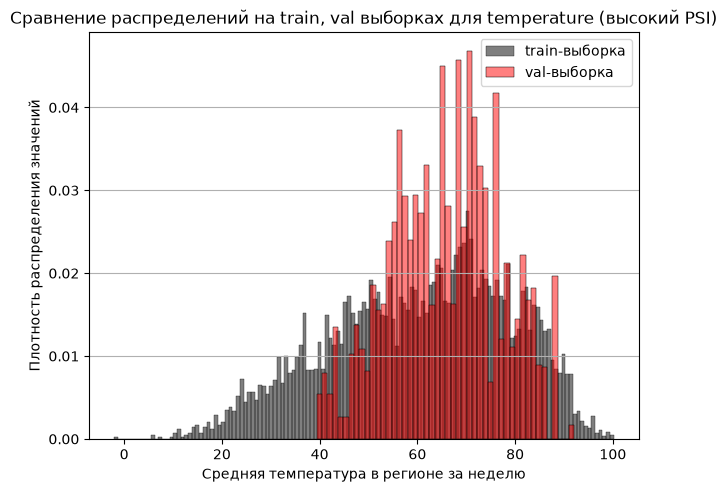

In [53]:
sns.histplot(train_df['temperature'], color='black', label='train-выборка', stat="density", alpha=0.5)
sns.histplot(val_df['temperature'], color='red', label='val-выборка', stat="density", alpha=0.5)
plt.tight_layout()
plt.title('Сравнение распределений на train, val выборках для temperature (высокий PSI)')
plt.xlabel('Средняя температура в регионе за неделю')
plt.ylabel('Плотность распределения значений')
plt.legend()
plt.grid(axis='y')

Для `temperature`, PSI которого равен 3.122, видна уже бОльшая схожесть между формами распределений - они оба напоминают нормальное распределение с тем отличием, что у тренировочной выборки оно скошено влево. Но различия все еще выявляются - например, пики плотности имеют разную форму.

Теперь построим график для признака с низким PSI.

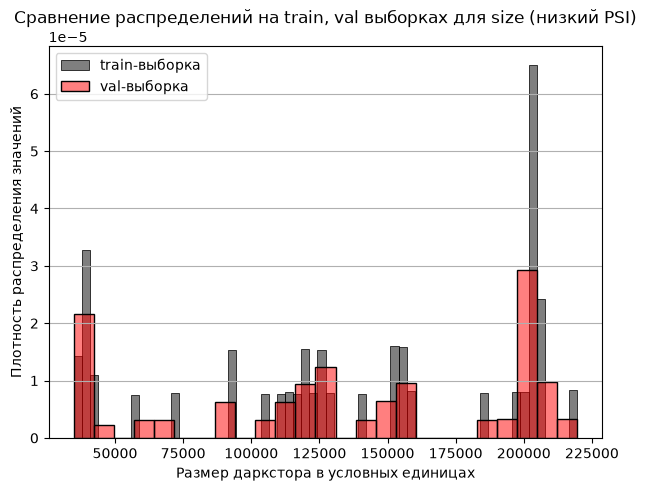

In [54]:
sns.histplot(train_df['size'], color='black', label='train-выборка', stat="density", alpha=0.5)
sns.histplot(val_df['size'], color='red', label='val-выборка', stat="density", alpha=0.5)
plt.tight_layout()
plt.title('Сравнение распределений на train, val выборках для size (низкий PSI)')
plt.xlabel('Размер даркстора в условных единицах')
plt.ylabel('Плотность распределения значений')
plt.legend()
plt.grid(axis='y')

Как видно из графика, для признака `size` с низким PSI (0.0001) распределения тренировочной и валидационной выборок почти повторяют друг друга - имеют похожую форму, пики и провалы.

Признаками с высоким PSI оказались:

In [55]:
high_psi = ['temperature',
            'fuel_price',
            'factor1',
            'factor2',
            'factor4',
            'cpi',
            'unemployment',
            'month',
            'quarter',
            'year']

Из этих признаков большинство действительно могут только помешать обучению модели, например, факторы рекламных акций и скидок, которые являются непостоянными и изначально могут не оказывать сильного влияния на покупательский спрос; уровень безработицы, температура, цена бензина и индекс потребительских цен - так как они претерпевают изменения из года в год; год - модель может уловить неправильный тренд и провести некорректную экстраполяцию. В то же время хоть месяц и квартал имеют высокий PSI - это происходит из-за того, что тренировочная выборка охватывает несколько лет, а валидационная всего несколько месяцев. Однако они несут в себе важную информацию о сезонности, которая была определена в начале проекта, и при удалении этих признаков есть риск потерять ее.

Таким образом, стоит удалить все признаки с PSI >= 0.2, кроме `month` и `quarter`.

In [56]:
high_psi.remove('month')
high_psi.remove('quarter')

In [57]:
for feature in high_psi:
    train_df = train_df.drop(feature, axis=1)
    val_df = val_df.drop(feature, axis=1)

In [58]:
train_df.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'is_holiday', 'type', 'size',
       'factor3', 'factor5', 'month', 'quarter', 'avg_sales_before',
       'sales_1week_ago', 'sales_2week_ago', 'sales_4week_ago',
       'mean_sales_2week', 'mean_sales_4week'],
      dtype='str')

Признаки были удалены успешно.

### Шаг 4. Обучение модели CatBoost

Создадим модель CatBoost. Подготовим выборки и признаки. При этом учтем, что модель не должна работать напрямую с датами и что `store` и `dept` по сути не несут в себе числовой инфорации, а скорее относятся к категориальным признакам, значит передадим их как категориальные.

In [59]:
train_df = train_df.drop('date', axis=1)
val_df = val_df.drop('date', axis=1)

In [60]:
X_train = train_df.drop('weekly_sales', axis=1)
y_train = train_df['weekly_sales']

X_val = val_df.drop('weekly_sales', axis=1)
y_val = val_df['weekly_sales']

In [61]:
cb = CatBoostRegressor(random_state=RANDOM_STATE,
                          early_stopping_rounds=200,
                          use_best_model=True,
                          verbose=200)

Обучим модель.

In [62]:
cb.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=['type', 'store', 'dept']
)

Learning rate set to 0.129648
0:	learn: 20194.8919455	test: 19178.3350866	best: 19178.3350866 (0)	total: 287ms	remaining: 4m 46s
200:	learn: 4184.9636427	test: 3042.1425863	best: 3018.1102224 (136)	total: 25.1s	remaining: 1m 39s
400:	learn: 3756.2797131	test: 3017.4435969	best: 3009.6485865 (390)	total: 51.8s	remaining: 1m 17s
600:	learn: 3521.7316644	test: 2988.7637607	best: 2988.5246370 (598)	total: 1m 18s	remaining: 52.1s
800:	learn: 3357.5774244	test: 2959.9838911	best: 2959.9838911 (800)	total: 1m 45s	remaining: 26.1s
999:	learn: 3243.1518875	test: 2955.9105034	best: 2954.6446802 (979)	total: 2m 11s	remaining: 0us

bestTest = 2954.64468
bestIteration = 979

Shrink model to first 980 iterations.


CatBoostRegressor(early_stopping_rounds=200, loss_function='RMSE', random_state=42, use_best_model=True, verbose=200)

Была  обучена модель, добавлен контроль переобучения - метрики оставались примерно одинаковыми и на валидационной, и на тренировочной выборках - модель не переобучена. 

Оценим качество модели на валидационной выборке. Для этого используем метрики:
- MAE;
- RMSE;
- R².

In [63]:
predict = cb.predict(X_val)

In [64]:
print(f"""MAE: {mean_absolute_error(y_val, predict)}
RMSE: {root_mean_squared_error(y_val, predict)}
R^2: {r2_score(y_val, predict)}
""")

MAE: 1362.9135437558884
RMSE: 2954.6446758369934
R^2: 0.9816176340803969



Модель объясняет 98% данных, предсказанные недельные продажи отдела отличаются на 1394 от реальных в абсолютной величине, корень из среднеквадратичной ошибки составляет 2929, что немного выше средней абсолютной ошибки за счет того, что данная метрика возводит ошибки в квдарат, но разница небольшая, а значит модель не допускает критичных ошибок на данных с большими значениями. В целом, модель продемонстрировала достаточно высокое качество прогнозирования. 

Проанализируем важность признаков.


In [65]:
importances = pd.DataFrame({'Признак': list(X_val.columns),
                            'Важность': list(cb.feature_importances_)}).sort_values(by='Важность', ascending=False).set_index('Признак')

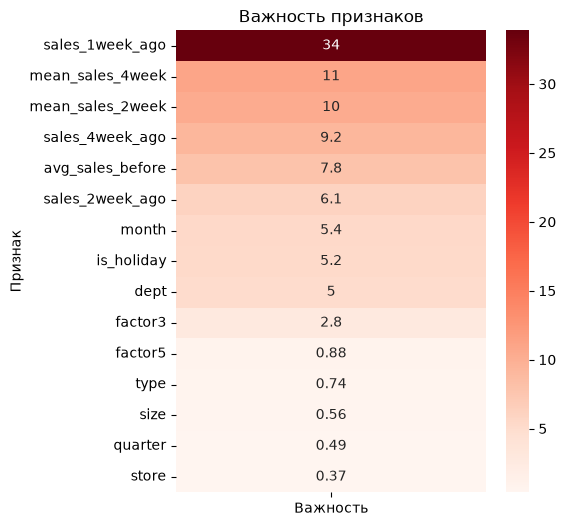

In [66]:
plt.figure(figsize=(5, 6))
sns.heatmap(importances,
            cmap='Reds',
            annot=True)
plt.title('Важность признаков')
plt.show()

Сильнее всего на модель оказал влияние признак `sales_1week_ago` (38), отвечающий за продажи неделю назад. Чем больше продаж уже было совершено, тем больше будет совершено в будущем. Так же для модели оказались важны `mean_sales_4week` (9.7), `mean_sales_2week` (9.4), `sales_4week_ago` (9.3), `avg_sales_before` (8.2) - модели важно видеть не только последнюю неделю, но и среднее за месяц и тренд месячной давности.

В топе признаков нет признаков, которые могли бы допустить утечку данных. Для модели в топе важности оказались признаки, созданные вручную.

Сохраним обученную модель в S3 для дальнейшего использования в batch-инференсе.

In [ ]:
import io
import pickle
import boto3
import os
from dotenv import load_dotenv
load_dotenv()


s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)


filebuffer = io.BytesIO()
pickle.dump(cb, filebuffer)
filebuffer.seek(0)


s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='catboost_model.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260715-9cbb8126d8/catboost_model.pkl
